# TFT Model for Energy Price in Spain

TFT (Temporal Fusion Transformer)
N-BeatsX (N-Beats with Exogenous Variables)
N-HiTS (Neural Hierarchical Interpolation for Time Series Forecasting)

## Why Transformers

Transformers, originally developed for natural language processing, have become a powerful tool for time series forecasting. Transformers take a matrix of features x timesteps as input, with each timestep encoded individually using position encoding and the self-attention mechanism. These techniques allow the model to capture both short- and long-range dependencies in the data whilst the temporal and sequential structure is maintained, unlike in FNNs (Feedforward Neural Networks), which collapse the data into a single column before encoding.

For energy demand forecasting, transformers can process multiple input features simultaneously, including lagged demand values, weather conditions, calendar effects, and other exogenous variables, without relying on manually defined temporal dependencies. 

The table below highlights how a Transformer is well-suited to predicting energy demand compared with other neural-network-based machine learning methods:

| Feature                            | Transformer                                 | RNN/LSTM/GRU                             | FNN (Feedforward Neural Network)        | CNN (Convolutional Neural Network)       |
|------------------------------------|---------------------------------------------|------------------------------------------|------------------------------------------|------------------------------------------|
| **Architecture Type**              | Attention-based (self-attention)            | Sequential (recurrence-based)            | Fully connected layers (no recurrence)   | Convolutional layers (local receptive fields) |
| **Handling of Long-Term Dependencies** | Excellent (self-attention)                 | Limited (vanishing/exploding gradients)  | None (treats all inputs as independent)  | Limited (focuses on local features)      |
| **Scalability**                    | High (parallel processing of large data)    | Low (sequential processing)              | High (processing all features in parallel)| High (parallel processing of convolutions) |
| **Training Time**                  | Faster (due to parallelisation)             | Slower (sequential training)             | Fast (simple architecture)               | Moderate (depends on depth of network)   |
| **Multi-Output Prediction**        | Very effective for multi-output tasks       | Challenging (often requires multiple models or complex architectures) | Challenging (often requires separate models) | Effective (can use same model for multiple outputs) |
| **Handling Complex Temporal Relationships** | Good (learns relationships with long-range dependencies) | Poor for long sequences due to vanishing gradients | Poor (no temporal awareness)             | Limited (focuses on local patterns, not temporal) |




## Choosing a Transformer Architecture

The model needs to generate 24 hourly predictions for the next day at noon, meaning it must capture sequential dependencies effectively. There are two main transformer architectures to consider:

- **Sequence-to-Sequence (Seq2Seq) Transformer** : This approach uses both an encoder and a decoder. The encoder processes historical data (past demand, weather, etc), extracting meaningful representations. The decoder autoregressively generates each hour’s demand forecast while attending to both the encoder’s outputs and known future data (weather forecasts, calendar effects, etc).
    - Pros : Naturally handles multi-step forecasting by generating predictions one at a time. Can incorporate past predictions dynamically in an autoregressive manner.
    - Cons : Requires masking to ensure predictions don’t leak future information. More computationally expensive due to the decoder’s sequential nature.
- **Encoder-Only Transformer** : This approach uses only an encoder (like BERT-style transformers) to map historical and exogenous features directly to all 24 future hourly predictions in a single forward pass.
    - Pros : Faster and more efficient since it doesn’t require iterative decoding. Avoids error accumulation from autoregressive predictions.
    - Cons : Can struggle with capturing temporal dependencies between consecutive predicted hours. Less flexible in handling exogenous variables that evolve dynamically.

For this task, an encoder-only transformer will be used since it efficiently predicts all 24 future time steps in one forward pass. While Seq2Seq models better capture sequential dependencies, their computational cost and risk of accumulating errors make them less suitable for predicting 36 hours ahead (12 historical + 24 future time steps).

In [1]:
import pandas as pd
import numpy as np
import torch
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.models.temporal_fusion_transformer import TemporalFusionTransformer
import lightning.pytorch as pl
import torchmetrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

## Feature Engineering

The pre-cleaned dataset from [xgboost_demand.ipynb](xgboost_demand.ipynb) can be reused for the transformer model, but adjustments are needed in the feature engineering step. Unlike XGBoost, which treated each time step as a separate row with extracted lag-based features, the transformer model requires the data to be structured as a sequence. This means that instead of having a single feature vector per prediction (num_features), the input to the transformer will be a (24, num_features) matrix, preserving the temporal relationships within each 24-hour window.

In [ ]:
df = pd.read_csv('data/price_df.csv')
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

cities = ['madrid', 'barcelona', 'valencia', 'sevilla', 'bilbao']

# City energy generation weights
solar_weights = {'madrid' : 0.239902,
                'barcelona' : 0.011677,
                'valencia' : 0.123509,
                'sevilla' : 0.585001,
                'bilbao' : 0.039911}

wind_weights = {'madrid' : 0.335746,
                'barcelona' : 0.023246,
                'valencia' : 0.300172,
                'sevilla' : 0.103898,
                'bilbao' : 0.236938}

hydro_weights = {'madrid' : 0.481331,
                'barcelona' : 0.135433,
                'valencia' : 0.191780,
                'sevilla' : 0.089994,
                'bilbao' : 0.101462}    

df_final = df[['datetime', 'Energy Price (EUR/MWh)', 'Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Hydro Pumped Storage Consumption', 'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Nuclear', 'Other renewable', 'Solar', 'Waste', 'Wind Onshore', 'Other', 'Hydro Pumped Storage Generation', 'Actual Total Load (MW)', 'predicted_demand', 'holiday_bool', 'MIBGAS Daily Price [EUR/MWh]']].copy()

solar_columns = ['temp', 'dew', 'humidity', 'cloudcover', 'visibility', 'solarradiation']
wind_columns = ['windgust', 'windspeed', 'winddir', 'sealevelpressure']
hydro_columns = ['precip', 'snow', 'snowdepth']

for column in solar_columns:
    df_final[f'solar_weighted_{column}'] = sum(df[f'{column}_{city}'] * weight for city, weight in solar_weights.items())
for column in wind_columns:
    df_final[f'wind_weighted_{column}'] = sum(df[f'{column}_{city}'] * weight for city, weight in wind_weights.items())
for column in hydro_columns:
    df_final[f'hydro_weighted_{column}'] = sum(df[f'{column}_{city}'] * weight for city, weight in hydro_weights.items())
df_final = df_final.round(2)

df_final = df_final.set_index('datetime')

df_final['date'] = df_final.index.date
df_final['hour'] = df_final.index.hour
df_final['day_of_week'] = df_final.index.dayofweek
df_final['month'] = df_final.index.month - 1  # Minus 1 to fit to range 0-11 instead of 1-12
df_final['year'] = df_final.index.year - 2018

# Cyclical encoding of features for hour, day_of_week and month
df_final['hour_sin'] = np.sin(2 * np.pi * df_final['hour'] / 24)
df_final['hour_cos'] = np.cos(2 * np.pi * df_final['hour'] / 24)
df_final['day_of_week_sin'] = np.sin(2 * np.pi * df_final['day_of_week'] / 7)
df_final['day_of_week_cos'] = np.cos(2 * np.pi * df_final['day_of_week'] / 7)
df_final['month_sin'] = np.sin(2 * np.pi * df_final['month'] / 12)
df_final['month_cos'] = np.cos(2 * np.pi * df_final['month'] / 12)

df_final.drop(['date', 'hour', 'day_of_week', 'month'], axis=1, inplace=True)
df_final = df_final[168:-1]

print(df_final.shape)
print(df_final.columns)

(43680, 39)
Index(['Energy Price (EUR/MWh)', 'Biomass', 'Fossil Gas', 'Fossil Hard coal',
       'Fossil Oil', 'Hydro Pumped Storage Consumption',
       'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Nuclear',
       'Other renewable', 'Solar', 'Waste', 'Wind Onshore', 'Other',
       'Hydro Pumped Storage Generation', 'Actual Total Load (MW)',
       'predicted_demand', 'holiday_bool', 'MIBGAS Daily Price [EUR/MWh]',
       'solar_weighted_temp', 'solar_weighted_dew', 'solar_weighted_humidity',
       'solar_weighted_cloudcover', 'solar_weighted_visibility',
       'solar_weighted_solarradiation', 'wind_weighted_windgust',
       'wind_weighted_windspeed', 'wind_weighted_winddir',
       'wind_weighted_sealevelpressure', 'hydro_weighted_precip',
       'hydro_weighted_snow', 'hydro_weighted_snowdepth', 'year', 'hour_sin',
       'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin',
       'month_cos'],
      dtype='object')


In [3]:
df_final["time_idx"] = range(len(df_final))
df_final["group_id"] = "single_series"

training = TimeSeriesDataSet(
    df_final[:34944],
    time_idx="time_idx",
    group_ids=["group_id"],
    target="Energy Price (EUR/MWh)",
    max_encoder_length=168,  # Lookback period
    max_prediction_length=35,  # Forecast horizon
    time_varying_known_reals=['predicted_demand', 'holiday_bool',
        'solar_weighted_temp', 'solar_weighted_dew', 'solar_weighted_humidity',
        'solar_weighted_cloudcover', 'solar_weighted_visibility',
        'solar_weighted_solarradiation', 'wind_weighted_windgust',
        'wind_weighted_windspeed', 'wind_weighted_winddir',
        'wind_weighted_sealevelpressure', 'hydro_weighted_precip',
        'hydro_weighted_snow', 'hydro_weighted_snowdepth', 'year', 'hour_sin',
        'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin',
        'month_cos'],  # Time-varying real features (known in the future)
    time_varying_unknown_reals=['Energy Price (EUR/MWh)', 'Biomass', 'Fossil Gas', 'Fossil Hard coal',
        'Fossil Oil', 'Hydro Pumped Storage Consumption',
        'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Nuclear',
        'Other renewable', 'Solar', 'Waste', 'Wind Onshore', 'Other',
        'Hydro Pumped Storage Generation', 'Actual Total Load (MW)', 'MIBGAS Daily Price [EUR/MWh]'],  # Time-varying real features (unknown in the future)
)
print(f'Training Dataset Length: {len(training)}')

test = TimeSeriesDataSet(
    df_final[34944:],
    time_idx="time_idx",
    group_ids=["group_id"],
    target="Energy Price (EUR/MWh)",
    max_encoder_length=168,  # Lookback period
    max_prediction_length=35,  # Forecast horizon
    time_varying_known_reals=['predicted_demand', 'holiday_bool',
        'solar_weighted_temp', 'solar_weighted_dew', 'solar_weighted_humidity',
        'solar_weighted_cloudcover', 'solar_weighted_visibility',
        'solar_weighted_solarradiation', 'wind_weighted_windgust',
        'wind_weighted_windspeed', 'wind_weighted_winddir',
        'wind_weighted_sealevelpressure', 'hydro_weighted_precip',
        'hydro_weighted_snow', 'hydro_weighted_snowdepth', 'year', 'hour_sin',
        'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin',
        'month_cos'],  # Time-varying real features (known in the future)
    time_varying_unknown_reals=['Energy Price (EUR/MWh)', 'Biomass', 'Fossil Gas', 'Fossil Hard coal',
        'Fossil Oil', 'Hydro Pumped Storage Consumption',
        'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Nuclear',
        'Other renewable', 'Solar', 'Waste', 'Wind Onshore', 'Other',
        'Hydro Pumped Storage Generation', 'Actual Total Load (MW)', 'MIBGAS Daily Price [EUR/MWh]'],  # Time-varying real features (unknown in the future)
)
print(f'Test Dataset Length: {len(test)}')

# Create DataLoaders
train_dataloader = training.to_dataloader(train=True, batch_size=64, shuffle=False, num_workers=10, persistent_workers=True)
test_dataloader = test.to_dataloader(train=False, batch_size=64, shuffle=False)
print(f'Training Batches: {len(train_dataloader)}')
print(f'Test Batches: {len(test_dataloader)}')

Training Dataset Length: 34742
Test Dataset Length: 8534
Training Batches: 542
Test Batches: 134


In [4]:
print("Torch version:", torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

Torch version: 2.2.2+cu121
True
NVIDIA RTX 2000 Ada Generation Laptop GPU


In [ ]:
# Define the TFT model
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.0005,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.4,
    lstm_layers=2,
    hidden_continuous_size=8,
    loss=torchmetrics.MeanSquaredError(),
    reduce_on_plateau_patience=5,
)

# Train the model
trainer = pl.Trainer(max_epochs=20, accelerator="auto")
trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=test_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | TorchMetricWrapper              | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 0      | train
3  | prescalers                         | ModuleDict                      | 624    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 0      | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 83.2 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 42.8 K | train
7  | static_cont

Epoch 20: 100%|██████████| 542/542 [02:53<00:00,  3.13it/s, v_num=3, train_loss_step=944.0, val_loss=467.0, train_loss_epoch=371.0]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 0: 100%|██████████| 542/542 [02:53<00:00,  3.12it/s, v_num=3, train_loss_step=944.0, val_loss=467.0, train_loss_epoch=371.0]


In [6]:
tft = TemporalFusionTransformer.load_from_checkpoint(
    "./models/price_tft_model.ckpt"
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


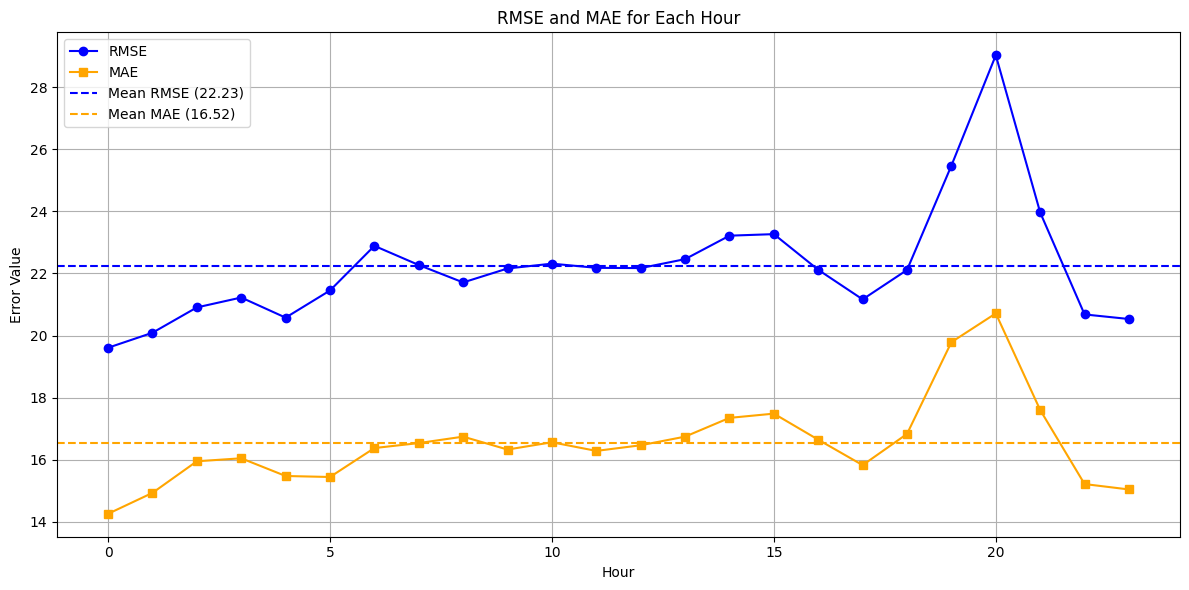

In [7]:
# Predict
raw_predictions, x, index, decoder_lengths, scale = tft.predict(test_dataloader, mode="raw", return_x=True)

predicted_values = raw_predictions["prediction"].detach().cpu().numpy()
actual_values = x['decoder_target'].detach().cpu().numpy()
indices = x['decoder_time_idx'].detach().cpu().numpy()

valid_indices = indices[:, 0] % 24 == 13  # Only consider predictions where first prediction is at 1pm

# Filter the predicted and actual values
filtered_predicted_values = predicted_values[valid_indices]
filtered_actual_values = actual_values[valid_indices]

filtered_predicted_values = filtered_predicted_values.squeeze(-1)

mae = mean_absolute_error(filtered_actual_values, filtered_predicted_values, multioutput='raw_values')
rmse = np.sqrt(mean_squared_error(filtered_actual_values, filtered_predicted_values, multioutput='raw_values'))
mean_rmse = np.mean(rmse[11:])
mean_mae = np.mean(mae[11:])

plt.figure(figsize=(12, 6))
plt.plot(rmse[11:], label='RMSE', marker='o', linestyle='-', color='blue')
plt.plot(mae[11:], label='MAE', marker='s', linestyle='-', color='orange')
plt.axhline(mean_rmse, color='blue', linestyle='--', label=f'Mean RMSE ({mean_rmse:.2f})')
plt.axhline(mean_mae, color='orange', linestyle='--', label=f'Mean MAE ({mean_mae:.2f})')
plt.title('RMSE and MAE for Each Hour')
plt.xlabel('Hour')
plt.ylabel('Error Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The transformer model requires more training data than XGBoost, so using one data point per day is insufficient. To address this, we will create one data point for each hour of the day, increasing the amount of training data and allowing the model to learn richer temporal patterns. While the transformer will still only make predictions for each hour (0-23) of the following day at noon, using data for other hours can still provide valuable context. This extra data can help the model capture long-term trends, making it more generalised and improving its overall forecasting accuracy.

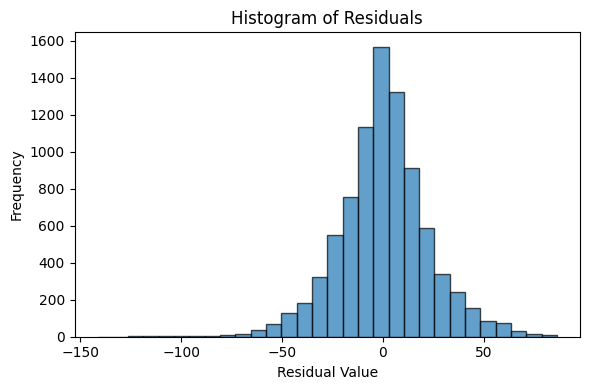

In [8]:
y_errors = filtered_predicted_values[:,11:]-filtered_actual_values[:,11:]
y_errors_flattened = y_errors.flatten()

plt.figure(figsize=(6, 4))
plt.hist(y_errors_flattened, bins=30, edgecolor="k", alpha=0.7)
plt.title("Histogram of Residuals")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Summary

The Transformer model achieved a Root Mean Squared Error (RMSE) of 899.11 MW, a Mean Absolute Error (MAE) of 681.94 MW, and a Mean Absolute Percentage Error (MAPE) of 2.57%. Therefore, the model is 97.43% accurate. This is significantly better that the benchmark model, however it was still outperformed by the XGBoost model with RMSE of 851.66 MW, MAE of 632.62 MW, and MAPE of 2.39%.

The XGBoost model outperformed the Transformer model primarily due to the limited dataset size. The XGBoost model benefits from handcrafted lag-based features, which explicitly encode temporal dependencies. In contrast, the transformer model relies on self-attention to learn these relationships, which requires significantly more data to generalise effectively. Additionally, Transformers have higher model complexity, making them more prone to overfitting on small datasets, whereas XGBoost’s built-in regularisation techniques help maintain robust performance.

The histogram of residuals indicates that the Transformer model systematically overpredicts energy demand more often than it underpredicts. Since this effect was not observed in the XGBoost model, it is unlikely to be caused by bias in the training data. Instead, it may be a consequence of the Transformer being trained on a more generalised dataset, where predictions were made at every hour rather than specifically at noon each day, potentially reducing its ability to capture noon-specific demand patterns accurately.